# US Equities Panel: Feature Evaluation

Every feature built in [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) is a candidate: something that
might help rank stocks by their next-session return. This notebook takes them one at a
time, measures how well each one ranks, asks how much of that is chance given how many
were tried, and records a decision for each.

It reads the two feature files, the primary label file, and the walk-forward design in
`config/setup.yaml`. It writes two files into `evaluation/`: a per-feature ledger of
decisions and evidence, which [`20_strategy_synthesis/02_feature_evaluation`](../../20_strategy_synthesis/02_feature_evaluation.ipynb)
reads to build the cross-case-study comparison, and the daily correlation series the
ledger is computed from.

One feature at a time is a screen, not a model. Two features that each rank weakly can be
strong together, and a feature that ranks well alone can add nothing once another is
already in the model. What this stage produces is therefore an auditable record of the
evidence on each candidate, which [`06_linear`](06_linear.ipynb) and the model notebooks
after it weigh against each other.

**Learning objectives**

- Measure how well a feature orders stocks by their next-session return, by correlating
  the two across the stocks quoted on each session and averaging that daily correlation.
- Put an interval around that average that allows for the fact that consecutive daily
  correlations are not independent draws.
- Work out how many of the associations found would be expected from chance alone, given
  how many features were tested at once, and say what "how many were tested" means here.
- Score each feature separately in each walk-forward period, so an association carried by
  one episode can be told apart from one that repeats.
- Read average return by feature quintile to see whether the relationship is one a
  ranking-based strategy can act on.
- Identify features carrying the same evidence twice and keep one of each group.

**Book reference**: Chapter 7, Section 7.3 (Univariate feature-label evaluation) and
Section 7.4 (Search accounting and multiple testing).

**Prerequisites**: [`02_labels`](02_labels.ipynb),
[`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb) have been run.

In [1]:
"""Feature Evaluation - US Equities Panel.

Univariate screening of the Chapter 8 financial features and the Chapter 9 model-based
features against the primary forward-return label, with multiplicity control, fold
stability and redundancy, ending in a per-feature triage decision.
"""

import gc
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import (
    compute_ic_hac_stats,
    compute_ic_uncertainty,
    cross_sectional_ic_series,
)
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

from case_studies.utils.feature_engineering import quantile_profile
from utils.artifact_specs import load_setup_config, resolve_label_buffer, resolve_label_horizon
from utils.cv_splits import generate_cv_splits
from utils.data_quality import validate_modeling_inputs
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import (
    COLORS,
    FIGSIZE,
    add_message_title,
    show_with_alt,
    zero_line,
)

In [2]:
MAX_SYMBOLS = 0
SEED = 42

## Configuration

Six settings decide what this notebook does, and all six come from
`config/setup.yaml` rather than being typed here, so that the evaluation and the
training that follows it cannot drift apart.

The **primary label** is the forward return every feature is scored against, and its
**horizon** is how many sessions ahead that return is measured over. The horizon sets two
other things. It sets how far the evaluation has to stop short of the **holdout**, the
later block of history reserved for a single final measurement: a decision made on the
last session of the evaluation window must have its outcome known before the holdout
opens, or the screen has read a session it is not allowed to see. And it sets the
bandwidth of the standard error in Section C, because a return measured over several
sessions overlaps the next one and makes consecutive daily correlations dependent.

The **walk-forward design** - how many folds, how long each trains for, how long each is
then scored over - is the same one `04_model_based_features` fitted its features against,
and Section A checks that the two agree rather than assuming it.

The **smallest cross-section** worth correlating is derived from what the strategy this
case study builds would have to fill. `setup.yaml` sweeps a long-short book of up to
fifty names a side, so a session quoting fewer than a hundred names is one where the
ranking could not be acted on and its correlation is not evidence about this strategy.

In [3]:
CASE_STUDY_ID = "us_equities_panel"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

DATE_COL = "timestamp"
ENTITY_COL = "symbol"
JOIN_COLS = [DATE_COL, ENTITY_COL]

SETUP = load_setup_config(CASE_STUDY_ID)
PRIMARY_LABEL = SETUP["labels"]["primary"]
LABEL_BUFFER = resolve_label_buffer(CASE_STUDY_ID, PRIMARY_LABEL, SETUP)
assert LABEL_BUFFER, f"no label buffer configured for {PRIMARY_LABEL}"
LABEL_HORIZON = int(resolve_label_horizon(CASE_STUDY_ID, PRIMARY_LABEL, SETUP).rstrip("Dd"))
HOLDOUT_START = date.fromisoformat(str(SETUP["evaluation"]["holdout_start"]))
N_SPLITS = SETUP["evaluation"]["n_splits"]
TOP_K_PER_SIDE = max(SETUP["backtest"]["sweep"]["top_k_grid"][PRIMARY_LABEL])
MIN_CROSS_SECTION = 2 * TOP_K_PER_SIDE

set_global_seeds(SEED)

print(f"Label            {PRIMARY_LABEL}, the return over the next {LABEL_HORIZON} session")
print(f"Holdout          opens {HOLDOUT_START}; everything below stops before it")
print(f"Walk-forward     {N_SPLITS} folds of {SETUP['evaluation']['train_size']} training")
print(f"                 scored over {SETUP['evaluation']['val_size']} each")
print(f"Cross-section    at least {MIN_CROSS_SECTION} names quoted, which is both sides of a")
print(f"                 book holding {TOP_K_PER_SIDE} long and {TOP_K_PER_SIDE} short")

Label            fwd_ret_1d, the return over the next 1 session
Holdout          opens 2016-01-01; everything below stops before it
Walk-forward     16 folds of 10Y training
                 scored over 1Y each
Cross-section    at least 100 names quoted, which is both sides of a
                 book holding 50 long and 50 short


## A. Panel and the holdout seal

### The sessions the folds are cut from

A walk-forward fold is a training window followed by a later window the trained thing is
scored over, and the folds step backwards from the holdout so that the most recent one
ends as close to it as the label allows. `generate_cv_splits` cuts them by position on a
list of trading sessions, so which list it is given decides where every boundary falls.

`04_model_based_features` gave it the sessions of the eligible price panel, and its
output carries one row per session, symbol and fold. Reading the session list back off
that file is what makes fold 3 here the same window as fold 3 there.

In [4]:
temporal_scan = pl.scan_parquet(CASE_DIR / "features" / "model_based.parquet")
temporal_cols = [c for c in temporal_scan.collect_schema().names() if c not in (*JOIN_COLS, "fold")]
sessions = temporal_scan.select(DATE_COL).unique().sort(DATE_COL).collect()[DATE_COL].to_list()
print(f"{len(sessions):,} trading sessions, {sessions[0]} to {sessions[-1]}")

splits = [
    {k: (v.date() if hasattr(v, "date") else v) for k, v in split.items()}
    for split in generate_cv_splits(
        pl.DataFrame({DATE_COL: sessions}),
        case_study_id=CASE_STUDY_ID,
        label_buffer=LABEL_BUFFER,
        outcome_horizon=f"{LABEL_HORIZON}D",
    )
]
for split in splits:
    print(f"  Fold {split['fold']:>2}: scored over {split['val_start']} to {split['val_end']}")

7,094 trading sessions, 1990-01-30 to 2018-03-27


  Fold  0: scored over 2015-01-02 to 2015-12-30
  Fold  1: scored over 2014-01-02 to 2014-12-31
  Fold  2: scored over 2013-01-02 to 2013-12-31
  Fold  3: scored over 2011-12-29 to 2012-12-31
  Fold  4: scored over 2010-12-30 to 2011-12-28
  Fold  5: scored over 2009-12-30 to 2010-12-29
  Fold  6: scored over 2008-12-30 to 2009-12-29
  Fold  7: scored over 2007-12-31 to 2008-12-29
  Fold  8: scored over 2006-12-28 to 2007-12-28
  Fold  9: scored over 2005-12-28 to 2006-12-27
  Fold 10: scored over 2004-12-29 to 2005-12-27
  Fold 11: scored over 2003-12-29 to 2004-12-28
  Fold 12: scored over 2002-12-27 to 2003-12-26
  Fold 13: scored over 2001-12-27 to 2002-12-26
  Fold 14: scored over 2000-12-20 to 2001-12-26
  Fold 15: scored over 1999-12-22 to 2000-12-19


### Checking that these are the folds the features were fitted on

The claim above is that fold *k* means the same window in both notebooks, and it is worth
checking rather than stating. `04_model_based_features` writes every row it fitted or
emitted for a fold, so the earliest session carrying fold *k* in the file is that fold's
training start, and the latest is the last session it was scored over. The training start
is asserted: if fold *k* began somewhere else there, the join below would attach a value
fitted for one window to dates in another.

The scoring end is taken from the file rather than asserted against it, because these are
the values being read: a fold is scored over the sessions it actually emitted, and never
past the boundary the split derived here allows.

In [5]:
fold_span = (
    temporal_scan.group_by("fold")
    .agg(pl.col(DATE_COL).min().alias("first"), pl.col(DATE_COL).max().alias("last"))
    .collect()
)
spans = {int(r["fold"]): (r["first"], r["last"]) for r in fold_span.iter_rows(named=True)}
for split in splits:
    first, _ = spans[int(split["fold"])]
    assert first == split["train_start"], (
        f"fold {split['fold']} begins {first} in model_based.parquet but "
        f"{split['train_start']} here"
    )
val_windows = {
    int(s["fold"]): (s["val_start"], min(s["val_end"], spans[int(s["fold"])][1])) for s in splits
}
print(f"all {len(splits)} folds begin on the same session in both notebooks")

all 16 folds begin on the same session in both notebooks


### One value per session and symbol

A model-based feature has a different value for each fold, because each fold refitted it
on its own training window. A feature is out of sample only over the window its own fold
was scored on, so keeping each fold's rows inside that window - and dropping the extra
fold that exists only to produce features for the holdout - leaves exactly one value per
session and symbol. That is asserted, because a session falling inside two scoring windows
would take two values and quietly double the rows underneath every statistic below.

The step also fixes the span of everything that follows. The Chapter 8 features exist on
every session, but restricting them to the same union of scoring windows puts both sets of
features on the same dates, which is what makes their correlations comparable. A session
no fold was scored over carries no model-based value and drops out here; the count is
printed rather than left to the join.

In [6]:
in_own_window = pl.any_horizontal(
    [
        (pl.col("fold") == fold) & pl.col(DATE_COL).is_between(start, end)
        for fold, (start, end) in val_windows.items()
    ]
)
temporal = temporal_scan.filter(in_own_window).drop("fold").collect()
assert temporal.select(JOIN_COLS).is_duplicated().sum() == 0, (
    "scoring windows overlap; a fitted feature would take two values on one session"
)

covered = temporal[DATE_COL].unique().sort().to_list()
EVAL_START, EVAL_END = covered[0], covered[-1]
uncovered = sum(1 for d in sessions if EVAL_START <= d <= EVAL_END and d not in set(covered))
print(f"Evaluation window {EVAL_START} to {EVAL_END}, {len(temporal):,} rows")
print(f"{len(covered):,} sessions scored, {uncovered} inside the window scored by no fold")

Evaluation window 1999-12-22 to 2015-12-30, 7,171,856 rows
4,031 sessions scored, 0 inside the window scored by no fold


### The panel

The Chapter 8 features and the label join onto that frame on session and symbol. Both
joins are inner: a row is evaluated only where the feature, the model-based feature and
the realized label all exist.

In [7]:
financial_scan = pl.scan_parquet(CASE_DIR / "features" / "financial.parquet")
financial_cols = [c for c in financial_scan.collect_schema().names() if c not in JOIN_COLS]
label_scan = pl.scan_parquet(CASE_DIR / "labels" / f"{PRIMARY_LABEL}.parquet")
label_col = next(c for c in label_scan.collect_schema().names() if c not in JOIN_COLS)

in_window = pl.col(DATE_COL).is_between(EVAL_START, EVAL_END)
eval_panel = (
    financial_scan.filter(in_window)
    .join(temporal.lazy(), on=JOIN_COLS, how="inner")
    .join(label_scan.filter(in_window), on=JOIN_COLS, how="inner")
    .sort(JOIN_COLS)
    .collect()
)
del temporal
gc.collect()

if MAX_SYMBOLS > 0:
    keep = eval_panel.group_by(ENTITY_COL).len().sort("len", descending=True).head(MAX_SYMBOLS)
    eval_panel = eval_panel.filter(pl.col(ENTITY_COL).is_in(keep[ENTITY_COL]))
    MIN_CROSS_SECTION = min(MIN_CROSS_SECTION, MAX_SYMBOLS)
    print(f"Reduced run: {MAX_SYMBOLS} symbols, cross-section floor {MIN_CROSS_SECTION}")

all_feature_cols = financial_cols + temporal_cols
n_sessions = eval_panel[DATE_COL].n_unique()
print(f"Panel: {len(eval_panel):,} rows, {eval_panel[ENTITY_COL].n_unique():,} symbols")
print(f"       {n_sessions:,} sessions, {len(all_feature_cols)} candidate features")

Panel: 7,170,323 rows, 3,147 symbols
       4,031 sessions, 71 candidate features


### The seal

The holdout is a block of later history that nothing in the research pipeline may read
until a single configuration has been chosen. A screen that ranks features on data
reaching into it has spent the holdout before anyone meant to.

The condition is about the label's endpoint, not the date a decision would be taken on.
A decision taken on the last session of the panel is scored by a return that resolves the
label's horizon later, so it is that later session which has to fall before the boundary.
Counting those sessions on the panel's own list, rather than in calendar days, is what
makes the check right across weekends and market holidays.

In [8]:
last_decision = eval_panel[DATE_COL].max()
label_endpoint = sessions[sessions.index(last_decision) + LABEL_HORIZON]
assert label_endpoint < HOLDOUT_START, (
    f"the last decision session {last_decision} is scored by a return resolving "
    f"{label_endpoint}, on or after the holdout opening {HOLDOUT_START}"
)
print(f"Last decision {last_decision}, its return resolves {label_endpoint}")
print(f"Holdout opens {HOLDOUT_START}; nothing below reads a session on or after it")

Last decision 2015-12-30, its return resolves 2015-12-31
Holdout opens 2016-01-01; nothing below reads a session on or after it


### What the panel holds

Everything below is a statistic computed across the stocks quoted on one session, so how
many are quoted is what those statistics rest on. The count is not flat: this universe is
built from a price and turnover screen, and both the number of listed names and the
number clearing that screen move with the market. A correlation across a thousand names
and one across two and a half thousand are not equally precise, and the chart is where
that shows.

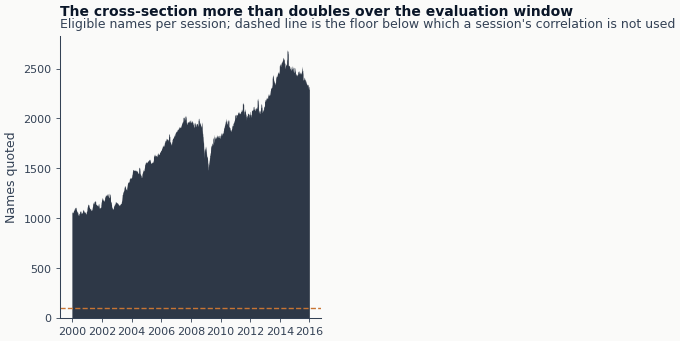

In [9]:
per_session = eval_panel.group_by(DATE_COL).len().sort(DATE_COL)
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
ax.fill_between(
    per_session[DATE_COL].to_list(),
    per_session["len"].to_list(),
    color=COLORS["blue"],
    alpha=0.85,
    linewidth=0,
)
ax.axhline(MIN_CROSS_SECTION, color=COLORS["copper"], linewidth=1.0, linestyle="--")
ax.set_ylabel("Names quoted")
ax.set_ylim(0, None)
add_message_title(
    ax,
    "The cross-section more than doubles over the evaluation window",
    subtitle=(
        "Eligible names per session; dashed line is the floor below which a session's "
        "correlation is not used"
    ),
)
show_with_alt(
    fig,
    "Filled area chart of the number of eligible stocks per trading session across the "
    "evaluation window. The count starts near one thousand, dips and recovers over the "
    "period, and ends more than twice as high. A dashed horizontal line near the bottom "
    "marks the minimum cross-section, which no session falls below.",
)

### The candidates, by construction

The other thing worth seeing before any of it is measured is what the candidates are.
Grouping them by what they are computed from is the classification
`03_financial_features` assigns, extended here to cover the model-based features, which
are named after their transform rather than their input. The groups matter twice over:
they are how Section G reads the redundancy, and they are why a count of candidates
overstates how many separate ideas are being tested. Several horizons of one return are
several columns and one idea.

In [10]:
def assign_feature_family(feature_name: str) -> str:
    """Return the construction a feature comes from.

    The first three rules are for the model-based features, which would otherwise be filed
    by a substring of their input: `ffd_log_volume` is a fractionally differenced series,
    not a liquidity measure. The rest is the classification `03_financial_features` uses, so
    a feature carries the same family in both notebooks. Blends and interactions are matched
    before their ingredients, so a composite of momentum ranks is a composite.
    """
    family_map = [
        (["wass_"], "regime"),
        (["ffd_"], "fractional_difference"),
        (["garch"], "conditional_volatility"),
        (["composite", "quality_", "spread", "_x_liq", "_x_size"], "composite"),
        (["mom_", "ret_", "skip_recent", "cumret"], "momentum"),
        (["rev_", "reversal", "str_"], "reversal"),
        (["vol_", "rv_", "realized", "natr", "range_", "mdd_"], "volatility"),
        (["sharpe_", "risk_adj"], "sharpe"),
        (["rsi", "macd", "adx", "cci", "stoch", "bb_", "aroon"], "technical"),
        (["sma_", "ema_", "kama_", "dist_from_52w", "trend"], "trend"),
        (["liq", "turnover", "volume", "amihud"], "liquidity"),
        (["size", "mktcap"], "size"),
    ]
    for prefixes, family in family_map:
        if any(p in feature_name.lower() for p in prefixes):
            return family
    return "other"


families = {f: assign_feature_family(f) for f in all_feature_cols}
unfamilied = sorted(f for f, fam in families.items() if fam == "other")
assert not unfamilied, f"features matching no family rule: {unfamilied}"

inventory = (
    pl.DataFrame({"feature": all_feature_cols})
    .with_columns(
        pl.col("feature").replace_strict(families).alias("family"),
        pl.col("feature")
        .replace_strict(
            {f: ("model_based" if f in temporal_cols else "financial") for f in families}
        )
        .alias("built_by"),
    )
    .group_by("family", "built_by")
    .len()
    .sort("len", descending=True)
)
display(inventory)

family,built_by,len
str,str,u32
"""momentum""","""financial""",17
"""trend""","""financial""",10
"""volatility""","""financial""",9
"""sharpe""","""financial""",9
"""technical""","""financial""",7
…,…,…
"""regime""","""model_based""",5
"""liquidity""","""financial""",3
"""fractional_difference""","""model_based""",2


## B. Correctness screens

Two different questions are asked before any association is measured, and it is worth
keeping them apart.

The first is whether the artifacts are intact: infinite values, returns too large to be
a real price move, feature columns that are empty. This is a property of what the
upstream notebooks wrote, and a failure here means going back to them.

The second is whether each individual feature can be trusted as of the moment a decision
would be made. Two things break that. **Coverage** is the share of panel rows where the
feature has a value at all; a feature present for a third of the panel is being scored on
a different, self-selected sample than its neighbours. **Staleness** is the share of rows
where the value is unchanged from the same symbol's previous session; a feature that
rarely moves cannot re-rank the cross-section, and when it comes from a periodic source it
may be repeating the last release rather than reporting new information.

Two further checks in the same family - that a feature's timestamp is the moment the
information was available, and that its mask lines up with the label's - are settled where
the feature is built, in `03_financial_features` and `04_model_based_features`.

In [11]:
MAX_ABS_RETURN = 1.0
COVERAGE_FLOOR = 0.70
STALENESS_CEILING = 0.50

gate = validate_modeling_inputs(
    features_df=eval_panel,
    label_df=eval_panel,
    feature_cols=all_feature_cols,
    label_col=label_col,
    join_cols=JOIN_COLS,
    asset_col=ENTITY_COL,
    max_abs_return=MAX_ABS_RETURN,
    fail_on_critical=True,
)

Data Quality Gate: 0 CRITICAL, 1 WARNING
  [!] WARNING: fwd_ret_1d has 24 values with |ret| > 100% (0.00% of 7,170,323 rows)


The gate runs on the panel Section A built, so the sessions it counts over all end before
the holdout opens. A one-session total return above one hundred percent is rare and real -
a small name on a takeover approach or a trial result - so the check reports how many
rows clear that bar rather than treating them as corrupt.

In [12]:
n_rows = len(eval_panel)
n_symbols = eval_panel[ENTITY_COL].n_unique()
coverage = {f: eval_panel[f].drop_nulls().len() / n_rows for f in all_feature_cols}

repeats = eval_panel.select(
    [(pl.col(f) == pl.col(f).shift(1).over(ENTITY_COL)).sum().alias(f) for f in all_feature_cols]
)
staleness = {f: float(repeats[f][0]) / max(n_rows - n_symbols, 1) for f in all_feature_cols}

correctness = {
    f: coverage[f] >= COVERAGE_FLOOR and staleness[f] <= STALENESS_CEILING for f in all_feature_cols
}
evaluable_features = [f for f in all_feature_cols if correctness[f]]
print(f"{len(evaluable_features)} of {len(all_feature_cols)} features clear both screens")

70 of 71 features clear both screens


In [13]:
stopped = [f for f in all_feature_cols if not correctness[f]]
display(
    pl.DataFrame(
        {
            "feature": stopped,
            "coverage": [coverage[f] for f in stopped],
            "staleness": [staleness[f] for f in stopped],
        },
        schema={"feature": pl.String, "coverage": pl.Float64, "staleness": pl.Float64},
    )
)

feature,coverage,staleness
str,f64,f64
"""wass_cluster""",1.0,0.975465


### Features with no cross-sectional variation

A rank correlation across the stocks quoted on a session needs the feature to differ
between them. Some of the model-based features describe the market rather than a stock -
a regime distance computed from the whole cross-section, a market-level conditional
volatility - so every symbol carries the same value on a given session and the
correlation is undefined.

These are not broken features. They are conditioning variables: things a model can use to
say *when* another feature works. What they cannot have is a cross-sectional correlation,
so they are separated here and carry that reason into the ledger.

In [14]:
cs_std = eval_panel.group_by(DATE_COL).agg([pl.col(f).std().alias(f) for f in evaluable_features])
date_level_features = {
    f for f in evaluable_features if (cs_std[f].drop_nulls().mean() or 0.0) < 1e-10
}
cs_features = [f for f in evaluable_features if f not in date_level_features]
print(f"Market-level (no cross-sectional variation): {sorted(date_level_features)}")
print(f"{len(cs_features)} features go forward to the correlation")

Market-level (no cross-sectional variation): ['mkt_garch_vol', 'wass_dist_max', 'wass_dist_min', 'wass_dist_ratio', 'wass_tail_div']
65 features go forward to the correlation


## C. Univariate association

The **information coefficient** is the rank correlation, across the stocks quoted on one
session, between a feature's value and the return that follows. It is computed once per
session, giving a series, and that series is then averaged. Holding the session fixed is
what makes it answer "which stock is better today", which is the only question a strategy
that ranks the cross-section every day ever asks.

A rank correlation is used rather than a linear one because the strategy only ever sorts:
it takes the top names and shorts the bottom, so what matters is the order the feature
puts stocks in, not the shape of the numbers.

The average is small by construction. It is an average over stocks and sessions of a
relationship that is mostly noise on any single one, and the reason it can still be worth
trading is breadth: independent bets on many names at once. That is what the average has
to be read against, and what the interval around it in the next section quantifies.

In [15]:
label_frame = eval_panel.select([*JOIN_COLS, label_col])
ic_series = {}
for i, feat in enumerate(cs_features, start=1):
    series = (
        cross_sectional_ic_series(
            eval_panel.select([*JOIN_COLS, feat]),
            label_frame,
            pred_col=feat,
            ret_col=label_col,
            date_col=DATE_COL,
            entity_col=ENTITY_COL,
            min_obs=MIN_CROSS_SECTION,
        )
        .drop_nulls("ic")
        .sort(DATE_COL)
    )
    if len(series) >= N_SPLITS:
        ic_series[feat] = series
    if i % 20 == 0:
        print(f"  {i}/{len(cs_features)} features")
print(f"IC series for {len(ic_series)} features over up to {n_sessions:,} sessions")

  20/65 features


  40/65 features


  60/65 features


IC series for 65 features over up to 4,031 sessions


### The interval around the average

Consecutive daily correlations are not independent draws. Features built from overlapping
windows drift slowly, so a session where a feature ranks well is more likely to be
followed by another, and a standard error that assumes independence is too narrow. The
Newey-West estimator widens it by however much serial correlation the series actually
shows, over a bandwidth set from the label horizon: a return measured over `h` sessions
overlaps the next `h - 1`, so the bandwidth is at least that.

The series is sorted before the estimator sees it. It reads values in the order it is
given, and a bandwidth applied to rows in the wrong order measures nothing.

In [16]:
ic_stats = {
    feat: compute_ic_hac_stats(series, ic_col="ic", label_horizon=LABEL_HORIZON)
    for feat, series in ic_series.items()
}
by_abs_ic = sorted(ic_stats, key=lambda f: abs(ic_stats[f]["mean_ic"]), reverse=True)
print(f"Newey-West bandwidth: {ic_stats[by_abs_ic[0]]['effective_lags']} sessions")

Newey-West bandwidth: 9 sessions


### The daily series, kept

The averages above are what the ledger carries, but the series they came from is the
object that shows whether an average is a steady small edge or one good year. It is
written out and read back for the chart below, which is also the cheapest check that the
file holds what the notebook thinks it does.

In [17]:
pl.concat(
    [series.with_columns(pl.lit(feat).alias("feature")) for feat, series in ic_series.items()]
).write_parquet(EVAL_DIR / "ic_timeseries.parquet")
ic_ts = pl.read_parquet(EVAL_DIR / "ic_timeseries.parquet")
print(f"Wrote evaluation/ic_timeseries.parquet: {len(ic_ts):,} rows read back")

Wrote evaluation/ic_timeseries.parquet: 262,015 rows read back


The chart follows the strongest feature from each of the four leading constructions
rather than the four largest averages, which on this panel are four ways of writing the
same volatility ranking and would draw one line four times.

The upper panel smooths each series over a year of trading, the same length as a fold,
because the raw daily correlation swings across most of its range within a week and a
line of it is unreadable. What to look for is whether a curve holds one side of zero or
crosses it: a feature whose average comes from one episode shows a spike and then a flat
stretch, and one that repeats holds its level across the window.

The lower panel puts three intervals on the same average. The naive one assumes
independent sessions, the Newey-West one allows for serial correlation, and the block
bootstrap resamples runs of consecutive sessions rather than assuming any particular form
for it. Where the three disagree, the naive one is the one to distrust.

In [18]:
ROLLING_SESSIONS = 252
leaders: list[str] = []
for feat in by_abs_ic:
    if families[feat] not in {families[f] for f in leaders}:
        leaders.append(feat)
    if len(leaders) == 4:
        break
leader_series = {f: ic_ts.filter(pl.col("feature") == f).sort(DATE_COL) for f in leaders}
uncertainty = {
    f: compute_ic_uncertainty(s, horizon=LABEL_HORIZON, ic_col="ic", seed=SEED)
    for f, s in leader_series.items()
}
print("Leading feature of each construction: " + ", ".join(leaders))

Leading feature of each construction: vol_zscore, sma_ratio_10, volume_ratio, ffd_log_volume


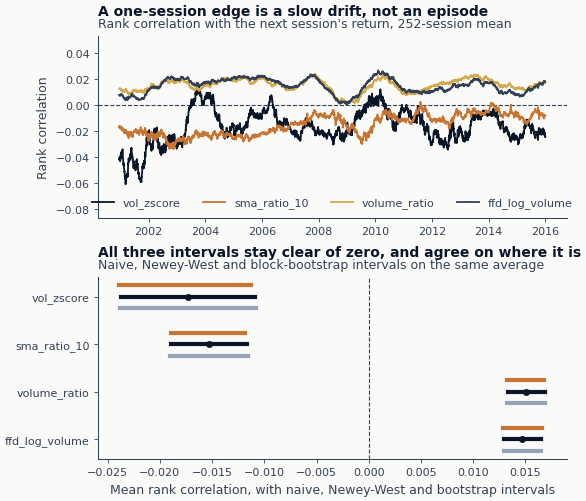

In [19]:
fig, (ax_series, ax_ci) = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], layout="constrained")
for feat, color in zip(leaders, ("blue", "copper", "amber", "neutral"), strict=False):
    s = leader_series[feat]
    ax_series.plot(
        s[DATE_COL].to_list(),
        s["ic"].rolling_mean(ROLLING_SESSIONS).to_list(),
        color=COLORS[color],
        linewidth=1.3,
        label=feat,
    )
zero_line(ax_series)
ax_series.set_ylabel("Rank correlation")
ax_series.margins(y=0.30)
ax_series.legend(fontsize=8, frameon=False, ncol=len(leaders), loc="lower center")

for row, feat in enumerate(leaders):
    u = uncertainty[feat]
    for offset, lo, hi, color in (
        (0.24, u["ci_naive_lower"], u["ci_naive_upper"], "recede"),
        (0.0, u["ci_hac_lower"], u["ci_hac_upper"], "blue"),
        (-0.24, u["ci_boot_lower"], u["ci_boot_upper"], "copper"),
    ):
        ax_ci.plot([lo, hi], [row + offset] * 2, color=COLORS[color], linewidth=3)
    ax_ci.plot(u["mean_ic"], row, marker="o", markersize=5, color=COLORS["blue"], zorder=3)
zero_line(ax_ci, axis="x")
ax_ci.set_yticks(range(len(leaders)), leaders, fontsize=8)
ax_ci.invert_yaxis()
ax_ci.set_xlabel("Mean rank correlation, with naive, Newey-West and bootstrap intervals")

add_message_title(
    ax_series,
    "A one-session edge is a slow drift, not an episode",
    subtitle=f"Rank correlation with the next session's return, {ROLLING_SESSIONS}-session mean",
)
add_message_title(
    ax_ci,
    "All three intervals stay clear of zero, and agree on where it is",
    subtitle="Naive, Newey-West and block-bootstrap intervals on the same average",
)
show_with_alt(
    fig,
    "Two stacked panels. The upper panel plots year-smoothed daily rank correlations for "
    "the leading feature of each of four constructions, with a zero reference line; the "
    "curves drift within a narrow band and cross zero only occasionally. The lower panel "
    "shows, for the same four features, the average correlation as a point with three "
    "horizontal intervals around it - naive, Newey-West and block bootstrap - all of "
    "similar width and all on the same side of zero.",
)

## D. Fold stability

One average over sixteen years can be produced by a relationship that held throughout or
by one that held in three years and not the rest, and those call for different decisions.
Scoring each walk-forward fold separately separates them.

The summary is the median across folds, the spread between the quartiles, the highest and
lowest fold, and how often a fold agrees with the feature's own direction. That last one
has to be measured against the feature's own sign: a feature that ranks stocks the wrong
way round is as useful as one that ranks them the right way, because the strategy can
sort in either direction, and counting positive folds would score a perfectly steady
inverse predictor at zero. For the same reason the fold worth looking at is the one
furthest against that direction, which for a negative predictor is its highest.

A fold counts towards that only where the feature was actually present across it, held to
the same coverage bar Section B applies to the panel. A feature that exists for a tenth of
a fold has a mean for that fold, and letting it vote alongside a fold it covers fully
would make the stability score partly a coverage score.

The bar that Section H later applies to that score is three folds in five agreeing, which
is the level Chapter 7's triage table sets: high enough that a feature flipping direction
in half its periods cannot pass, low enough that one bad regime does not disqualify one
that repeats elsewhere.

In [20]:
SIGN_CONSISTENCY_FLOOR = 0.60
sessions_per_fold = {
    fold: eval_panel.filter(pl.col(DATE_COL).is_between(start, end))[DATE_COL].n_unique()
    for fold, (start, end) in val_windows.items()
}

fold_stats = {}
for feat, series in ic_series.items():
    fold_ics = []
    for fold, (start, end) in val_windows.items():
        window = series.filter(pl.col(DATE_COL).is_between(start, end))
        if window.height >= max(1, COVERAGE_FLOOR * sessions_per_fold[fold]):
            fold_ics.append(float(window["ic"].mean()))
    if not fold_ics:
        continue
    median_ic = float(np.median(fold_ics))
    direction = 1.0 if median_ic >= 0 else -1.0
    # Weakest and strongest are read against the feature's own direction, the same way
    # sign consistency below is and the same way the chart marks them. For a feature that
    # ranks stocks inversely the weakest fold is its algebraic maximum, so exporting the
    # algebraic minimum under the name "worst" told a reader the opposite of the truth for
    # every such feature - and the ledger is what Chapter 20 reads.
    fold_stats[feat] = {
        "n_folds": len(fold_ics),
        "fold_ics": fold_ics,
        "median_fold_ic": median_ic,
        "fold_iqr": float(np.subtract(*np.percentile(fold_ics, [75, 25]))),
        "worst_fold_ic": min(fold_ics, key=lambda ic: ic * direction),
        "best_fold_ic": max(fold_ics, key=lambda ic: ic * direction),
        "sign_consistency": sum(1 for ic in fold_ics if ic * direction > 0) / len(fold_ics),
    }
n_stable = sum(1 for s in fold_stats.values() if s["sign_consistency"] >= SIGN_CONSISTENCY_FLOOR)
print(f"{len(fold_stats)} features scored fold by fold; {n_stable} hold their own direction")
print(f"in at least {SIGN_CONSISTENCY_FLOOR:.0%} of the folds they were scored on")

65 features scored fold by fold; 57 hold their own direction
in at least 60% of the folds they were scored on


The chart is one row per feature and one dot per fold, for the features with the largest
median. Read the horizontal spread: a tight row is a feature that behaved the same way in
every period, and a row with one dot far from the rest is an average carried by a single
fold. The bar marks the median and the open circle the fold that ran furthest against
the feature's own direction, which for a negative predictor is its highest fold, not
its lowest.

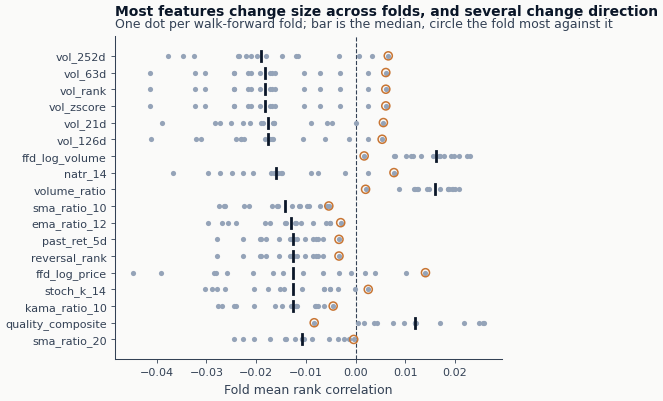

In [21]:
ranked = sorted(fold_stats, key=lambda f: abs(fold_stats[f]["median_fold_ic"]), reverse=True)[:18]
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
for row, feat in enumerate(ranked):
    s = fold_stats[feat]
    ax.scatter(
        s["fold_ics"], [row] * s["n_folds"], s=14, color=COLORS["recede"], zorder=2, linewidths=0
    )
    ax.plot([s["median_fold_ic"]] * 2, [row - 0.3, row + 0.3], color=COLORS["blue"], linewidth=2)
    ax.scatter(
        s["worst_fold_ic"],
        row,
        s=34,
        facecolors="none",
        edgecolors=COLORS["copper"],
        linewidths=1.1,
        zorder=3,
    )
zero_line(ax, axis="x")
ax.set_yticks(range(len(ranked)), ranked, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Fold mean rank correlation")
add_message_title(
    ax,
    "Most features change size across folds, and several change direction",
    subtitle="One dot per walk-forward fold; bar is the median, circle the fold most against it",
)
show_with_alt(
    fig,
    "Strip plot with one row per feature and one dot per walk-forward fold, showing each "
    "fold's mean rank correlation. Rows are ordered by the absolute median. A vertical bar "
    "marks each feature's median and an open circle marks the fold running furthest against "
    "its direction. Most rows spread "
    "across a range several times the width of their median, and many straddle the zero "
    "reference line.",
)

## E. Shape

A rank correlation says the ordering carries information but not how the return is
distributed along it. A strategy that goes long the top fifth and short the bottom fifth
needs the extremes to be the extremes: a feature whose middle quintile earns the most is
carrying real information that this particular strategy cannot collect.

Quintiles are assigned **within each session**, across the stocks quoted that day, for the
same reason the correlation is cross-sectional: the boundaries that decide which quintile
a stock falls in are then set by the stocks it is competing with that day, so the top
quintile means "ranked high today" and nothing else.

What is averaged inside each quintile is the return relative to the session's own average
return, not the raw return. Every quintile of every feature earns the market's drift, so
raw levels put five bars of almost equal height on the chart and hide the only quantity
the long-short book actually collects: the difference between the quintiles.

The average is taken twice, first across the stocks in a quintile on one session and then
across sessions, so every session counts once however many names it quoted. That is both
what the strategy earns - it rebalances every session and holds each quintile equally
weighted - and what keeps the profile comparable with the correlation above, which is
also a per-session statistic averaged over sessions.

The monotonicity score is the rank correlation between quintile number and that average:
one where it rises across every quintile, minus one where it falls across every quintile,
and near zero where the profile turns over in the middle.

The score can disagree in sign with the information coefficient of the same feature, and
that disagreement is the reason this section exists. The correlation is computed on the
ranks of the returns, so it counts how often a stock finishes above its neighbours; the
profile is computed on the returns themselves, so it is driven by how much. A feature that
picks stocks which lose slightly more often but win far larger when they win has a
negative correlation and a rising profile, and a long-short book sorted on it earns the
profile, not the correlation.

In [22]:
N_QUANTILES = 5
profiles = {}
for feat in by_abs_ic:
    profile = quantile_profile(
        eval_panel,
        feat,
        label_col,
        date_col=DATE_COL,
        n_quantiles=N_QUANTILES,
        min_cross_section=MIN_CROSS_SECTION,
        demean_within_date=True,
    )
    if profile is None:
        continue
    profiles[feat] = {
        "means": profile.means,
        "spread": profile.spread,
        "monotonicity": profile.monotonicity,
    }
monotonicity_scores = {f: p["monotonicity"] for f, p in profiles.items()}
disagree = [
    f
    for f in profiles
    if np.sign(profiles[f]["monotonicity"]) != np.sign(ic_stats[f]["mean_ic"])
    and profiles[f]["monotonicity"] != 0
]
print(f"Quintile profile for {len(profiles)} features, assigned within each session")
print(f"{len(disagree)} of them slope against the sign of their own correlation, led by")
print(", ".join(disagree[:4]))

Quintile profile for 64 features, assigned within each session
31 of them slope against the sign of their own correlation, led by
vol_zscore, vol_63d, vol_rank, vol_126d


/tmp/ipykernel_3831805/1596350566.py:28: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(hspace=0.15, wspace=0.2)


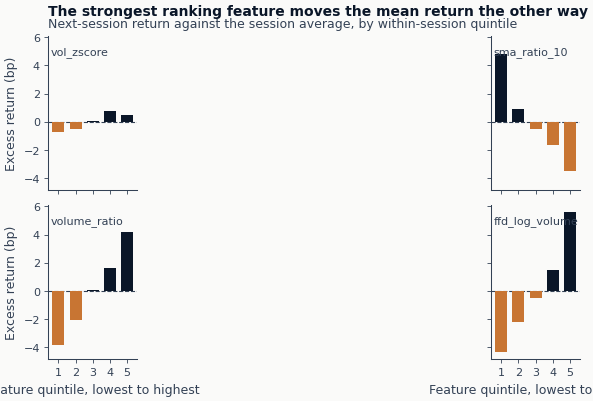

In [23]:
fig, axes = plt.subplots(2, 2, figsize=FIGSIZE["grid_2x2"], sharex=True, sharey=True)
for ax, feat in zip(axes.ravel(), leaders, strict=False):
    means = profiles[feat]["means"]
    ax.bar(
        range(1, len(means) + 1),
        [m * 1e4 for m in means],
        color=[COLORS["copper"] if m < 0 else COLORS["blue"] for m in means],
        width=0.7,
    )
    zero_line(ax)
    ax.annotate(
        feat,
        xy=(0.03, 0.88),
        xycoords="axes fraction",
        fontsize=8,
        color=COLORS["neutral"],
    )
    ax.set_xticks(range(1, len(means) + 1))
for ax in axes[-1]:
    ax.set_xlabel("Feature quintile, lowest to highest")
for ax in axes[:, 0]:
    ax.set_ylabel("Excess return (bp)")
add_message_title(
    axes[0, 0],
    "The strongest ranking feature moves the mean return the other way",
    subtitle="Next-session return against the session average, by within-session quintile",
)
fig.subplots_adjust(hspace=0.15, wspace=0.2)
show_with_alt(
    fig,
    "Four small bar charts, one per feature, each showing the average next-session return "
    "relative to the session's own average, in basis points, for stocks in each of five "
    "quintiles of that feature. Quintiles are assigned within each session and bars are "
    "coloured by sign against a zero reference line. Three panels slope steadily across a "
    "few basis points; the panel for the feature with the largest rank correlation is much "
    "flatter and rises where that correlation is negative.",
)

## F. Search accounting and multiple testing

Every association above was found by looking. With enough features, some will correlate
with the label by chance, and a p-value read one feature at a time does not account for
the others that were tried. So the number tried has to be declared before any of them is
called significant, and it is the count of features that reached a correlation - not the
count that survived it.

The search here is narrow and worth stating as such: one label, one horizon, one way of
computing the correlation, and no threshold or window swept. The only multiplicity is
across features.

The Benjamini-Hochberg procedure controls the **false discovery rate**: the expected share
of the features it calls significant that are not. That is a different guarantee from
controlling the chance of any false positive at all, and a deliberately weaker one -
at this stage the cost of missing a real feature is higher than the cost of carrying one
extra into a model that will screen it again.

In [24]:
FDR_ALPHA = 0.05
searched = list(ic_stats)
p_values = [ic_stats[f]["p_value"] for f in searched]
fdr = benjamini_hochberg_fdr(p_values, alpha=FDR_ALPHA, return_details=True)
fdr_significant = {f for f, r in zip(searched, fdr["rejected"], strict=True) if r}
fdr_by_feature = dict(zip(searched, (float(p) for p in fdr["adjusted_p_values"]), strict=True))

eval_summary = pl.DataFrame(
    {
        "feature": searched,
        "source": ["model_based" if f in temporal_cols else "financial" for f in searched],
        "ic_mean": [ic_stats[f]["mean_ic"] for f in searched],
        "hac_se": [ic_stats[f]["hac_se"] for f in searched],
        "hac_t": [ic_stats[f]["t_stat"] for f in searched],
        "hac_p": p_values,
        "fdr_p": list(fdr["adjusted_p_values"]),
        "fdr_sig": list(fdr["rejected"]),
        "naive_t": [ic_stats[f]["naive_t_stat"] for f in searched],
    }
).sort(pl.col("ic_mean").abs(), descending=True)

n_naive = sum(1 for p in p_values if p < FDR_ALPHA)
print(f"Searched set: {len(searched)} features, one label, one horizon")
print(f"  significant one at a time: {n_naive}")
print(f"  significant after the false-discovery correction: {int(fdr['n_rejected'])}")

Searched set: 65 features, one label, one horizon
  significant one at a time: 48
  significant after the false-discovery correction: 46


The upper panel ranks features by the size of the association and shades the ones the
correction still calls a discovery. Horizontal bars are used because the names are long,
and the ordering is by absolute value because a negative association is as usable as a
positive one: the strategy can sort either way round.

The lower panel is the diagnostic for Section C: each feature's t-statistic before and
after allowing for serial correlation. Points on the diagonal are features whose daily
correlations were near independent, so the wider bandwidth cost them nothing. Points
pulled towards the horizontal axis would be features whose apparent significance came
from persistence rather than from more evidence.

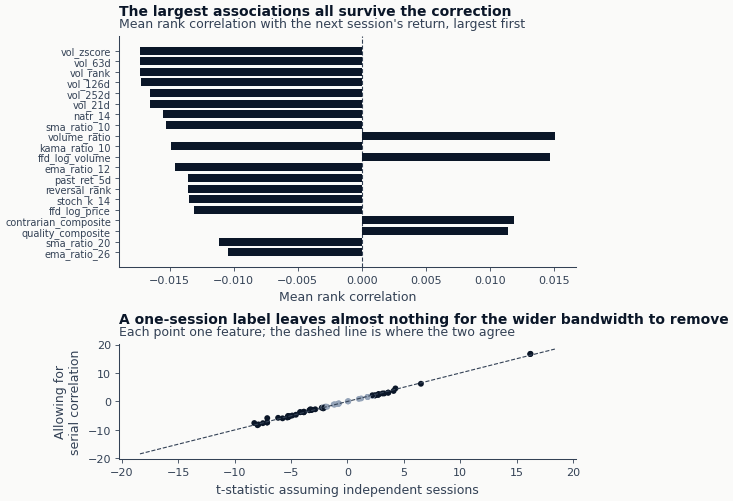

In [25]:
SHOWN_FEATURES = 20
top = eval_summary.head(SHOWN_FEATURES)
fig, (ax_bar, ax_t) = plt.subplots(
    2,
    1,
    figsize=FIGSIZE["dual_v"],
    gridspec_kw={"height_ratios": [2, 1]},
    layout="constrained",
)
ax_bar.barh(
    range(len(top)),
    top["ic_mean"].to_list(),
    color=[COLORS["blue"] if s else COLORS["recede"] for s in top["fdr_sig"].to_list()],
    height=0.75,
)
ax_bar.set_yticks(range(len(top)), top["feature"].to_list(), fontsize=7)
ax_bar.invert_yaxis()
zero_line(ax_bar, axis="x")
ax_bar.set_xlabel("Mean rank correlation")

ax_t.scatter(
    eval_summary["naive_t"].to_list(),
    eval_summary["hac_t"].to_list(),
    s=18,
    color=[COLORS["blue"] if s else COLORS["recede"] for s in eval_summary["fdr_sig"].to_list()],
    linewidths=0,
)
limit = 1.1 * max(
    eval_summary["naive_t"].abs().max() or 1.0, eval_summary["hac_t"].abs().max() or 1.0
)
ax_t.plot([-limit, limit], [-limit, limit], color=COLORS["neutral"], linewidth=0.8, linestyle="--")
ax_t.set_xlabel("t-statistic assuming independent sessions")
ax_t.set_ylabel("Allowing for\nserial correlation")

add_message_title(
    ax_bar,
    "The largest associations all survive the correction",
    subtitle="Mean rank correlation with the next session's return, largest first",
)
add_message_title(
    ax_t,
    "A one-session label leaves almost nothing for the wider bandwidth to remove",
    subtitle="Each point one feature; the dashed line is where the two agree",
)
show_with_alt(
    fig,
    "Two stacked panels. The upper panel is a horizontal bar chart of the twenty "
    "features with the largest average rank correlation, positive and negative, shaded "
    "where the feature survives the false-discovery correction; every bar shown is shaded. "
    "The lower panel is a scatter of each feature's t-statistic computed assuming "
    "independent sessions against the same statistic allowing for serial correlation, with "
    "a dashed diagonal; the points sit on the diagonal.",
)

In [26]:
print(f"Candidates                        {len(all_feature_cols)}")
print(f"Clear coverage and staleness      {len(evaluable_features)}")
print(f"  of those, market-level only     {len(date_level_features)}")
print(f"Have a cross-sectional IC         {len(ic_stats)}")
print(f"Significant one at a time         {n_naive}")
print(f"Significant after the correction  {int(fdr['n_rejected'])}")
print(
    f"Largest association               {eval_summary['feature'][0]} "
    f"at {eval_summary['ic_mean'][0]:+.4f}"
)
print(
    f"Cross-section                     {per_session['len'].min():,} to "
    f"{per_session['len'].max():,} names"
)

Candidates                        71
Clear coverage and staleness      70
  of those, market-level only     5
Have a cross-sectional IC         65
Significant one at a time         48
Significant after the correction  46
Largest association               vol_zscore at -0.0173
Cross-section                     1,024 to 2,692 names


Of 71 candidate features, 70 clear the coverage and staleness screens. Five of those vary
only through time and so cannot have a cross-sectional correlation, leaving 65 tested.
Testing one at a time makes 48 of them significant; controlling the false discovery rate
over the same 65 tests leaves 46. The largest association in the panel is vol_zscore at
-0.0173, measured across a cross-section running from 1,024 to 2,692 names.

## G. Redundancy and families

A long candidate list is not a long list of separate pieces of evidence. A twenty-one
session return and a forty-two session return over the same prices move together, and a
feature and its own cross-sectional rank move together exactly. Counting each as a
separate discovery overstates how much the panel knows, and it also inflated the
correction in Section F, which was told it had that many independent tests to control.

The sharpest case is worth measuring first, because a rank correlation is blind to it. If
two features order the stocks in a session identically - a return and its rank, a
volatility and its z-score - then their information coefficients are not merely close,
they are the same number to the last digit.

In [27]:
identical = (
    pl.DataFrame({"feature": list(ic_stats), "ic_mean": [s["mean_ic"] for s in ic_stats.values()]})
    .group_by("ic_mean")
    .agg(pl.col("feature").sort())
    .filter(pl.col("feature").list.len() > 1)
    .sort("ic_mean")
)
print(f"{len(identical)} groups of features share a mean correlation exactly:")
for row in identical.iter_rows(named=True):
    print(f"  {row['ic_mean']:+.6f}  {' = '.join(row['feature'])}")

10 groups of features share a mean correlation exactly:
  -0.017312  vol_63d = vol_rank
  -0.013540  past_ret_5d = reversal_rank
  -0.007523  rsi_14 = rsi_rank
  -0.007486  mom_rank_21d = past_ret_21d
  -0.001573  mom_rank_63d = past_ret_63d
  +0.000139  sharpe_63d = sharpe_rank_63d
  +0.003938  mom_rank_126d = past_ret_126d
  +0.005495  sharpe_126d = sharpe_rank_126d
  +0.005781  mom_rank_252d = past_ret_252d
  +0.007954  sharpe_252d = sharpe_rank_252d


The general case needs measuring. The **correlation clusters** below group features by how
strongly they move together, and one member of each group is kept to stand for the rest:
the member with the largest median fold correlation, breaking ties towards the one whose
folds disagree least. Both numbers come from Section D, and the choice is written into the
ledger so a reader can see which member survived and which was dropped for it. Being the
representative is not itself a promotion; it still has to earn its own decision in
Section H.

The correlation is measured on a sample of sessions rather than the whole panel. A rank
correlation between two features over seven million rows and over a few hundred thousand
differs in the fourth decimal, and the pairs worth acting on are the ones near one.

In [28]:
REDUNDANCY_CUT = 0.70
SAMPLE_TARGET = 200
step = max(1, n_sessions // SAMPLE_TARGET)
sampled = eval_panel[DATE_COL].unique().sort()[::step]
corr = (
    eval_panel.filter(pl.col(DATE_COL).is_in(sampled.implode()))
    .select(evaluable_features)
    .to_pandas()
    .corr(method="spearman")
)
pairs = [
    (a, b, float(corr.loc[a, b]))
    for i, a in enumerate(corr.columns)
    for b in corr.columns[i + 1 :]
    if abs(corr.loc[a, b]) > REDUNDANCY_CUT
]
pairs.sort(key=lambda p: -abs(p[2]))
print(f"{len(pairs)} feature pairs correlate above {REDUNDANCY_CUT:.2f}")
print(f"measured on {len(sampled)} sampled sessions")

248 feature pairs correlate above 0.70
measured on 202 sampled sessions


Clustering turns those pairs into groups. Two features are close when the absolute value
of their correlation is near one, so `1 - |correlation|` is the distance, and cutting the
tree at the same threshold used for the pair count makes the groups and the pairs answer
the same question.

In [29]:
distance = 1.0 - corr.abs().to_numpy()
np.fill_diagonal(distance, 0.0)
labels = hierarchy.fcluster(
    hierarchy.linkage(squareform(distance, checks=False), method="average"),
    t=1.0 - REDUNDANCY_CUT,
    criterion="distance",
)
clusters: dict[int, list[str]] = {}
for feat, cluster_id in zip(corr.columns, labels, strict=True):
    clusters.setdefault(int(cluster_id), []).append(feat)


def fold_standing(feature: str) -> tuple[float, float]:
    """Rank a cluster's members: strongest median fold correlation, then steadiest."""
    stats = fold_stats.get(feature)
    if stats is None:
        return (0.0, 0.0)
    return (abs(stats["median_fold_ic"]), -stats["fold_iqr"])


representative_of = {
    member: max(members, key=fold_standing) for members in clusters.values() for member in members
}
redundant = {f for members in clusters.values() for f in members if len(members) > 1}
n_multi = sum(1 for members in clusters.values() if len(members) > 1)
print(f"{len(clusters)} clusters, {n_multi} of them holding more than one feature")
print(f"{len(redundant)} features share a cluster; one of each is kept to stand for it")

24 clusters, 11 of them holding more than one feature
57 features share a cluster; one of each is kept to stand for it


The chart is the strongest pairs rather than the whole matrix. A grid of sixty-odd rows
and the same number of columns is mostly empty space with tick labels too small to read,
and the question the section asks is which specific pairs are duplicates. Both members of
a pair are named, and the feature its cluster keeps is named after them - which is often
neither of the two, because a cluster is usually larger than any one pair inside it.

~/ml4t/public-stage-05-assembly/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


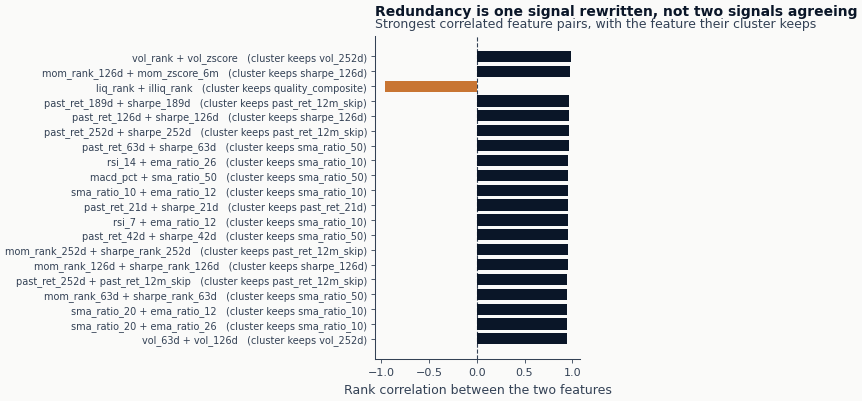

In [30]:
SHOWN_PAIRS = 20
shown_pairs = pairs[:SHOWN_PAIRS]
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])
ax.barh(
    range(len(shown_pairs)),
    [r for _, _, r in shown_pairs],
    color=[COLORS["blue"] if r > 0 else COLORS["copper"] for _, _, r in shown_pairs],
    height=0.75,
)
ax.set_yticks(
    range(len(shown_pairs)),
    [f"{a} + {b}   (cluster keeps {representative_of[a]})" for a, b, _ in shown_pairs],
    fontsize=7,
)
ax.invert_yaxis()
zero_line(ax, axis="x")
ax.set_xlabel("Rank correlation between the two features")
add_message_title(
    ax,
    "Redundancy is one signal rewritten, not two signals agreeing",
    subtitle="Strongest correlated feature pairs, with the feature their cluster keeps",
)
show_with_alt(
    fig,
    "Horizontal bar chart of the twenty most strongly correlated feature pairs, coloured "
    "by the sign of the correlation. Each row names both members of the pair and the "
    "feature kept to represent their cluster. Almost every bar reaches beyond plus or "
    "minus nine tenths, and the pairs are returns against their own ranks or risk-adjusted "
    "forms, and moving averages against each other.",
)

## H. Triage and handoff

Each feature gets one of three decisions, and the rule is stated before it is applied.

There are two ways to be carried forward. The first is the multiplicity-controlled test
from Section F: the association is large enough that the correction still calls it a
discovery. The second is an **exploration** route, and naming it that way matters. It
promotes a feature whose association is ordinary in size but steady in direction across
folds, on the grounds that fold stability is evidence a single t-statistic does not carry,
and that a screen at this stage should hand the modelling notebooks a menu. A feature
promoted that way has not been confirmed, and the ledger records which route fired so a
reader can tell the two apart.

The exploration route exists mainly for the case this case study is not in: a narrow
cross-section, where the correction is strict enough to empty the menu. Its bar is read
off the panel rather than chosen - the median association among the candidates that got
one - so a feature promoted through it is at least as strongly associated as the typical
candidate, and holds its direction in most folds. Whether it fires at all is a fact about
the data, and the funnel below is where to read it.

In [31]:
evaluated_ics = [abs(s["mean_ic"]) for s in ic_stats.values()]
IC_EXPLORATION_FLOOR = float(np.median(evaluated_ics)) if evaluated_ics else 0.0
print(f"Exploration route: |correlation| at least {IC_EXPLORATION_FLOOR:.4f}")
print(f"and direction held in {SIGN_CONSISTENCY_FLOOR:.0%} of folds")

Exploration route: |correlation| at least 0.0066
and direction held in 60% of folds


In [32]:
triage = {}
for feat in all_feature_cols:
    if not correctness[feat]:
        triage[feat] = ("STOP", "correctness_fail")
    elif feat in date_level_features:
        triage[feat] = ("REVISE", "no_cross_sectional_variation")
    elif feat not in ic_stats:
        triage[feat] = ("REVISE", "insufficient_sessions")
    elif feat in fdr_significant:
        triage[feat] = ("PROCEED", "fdr_significant")
    elif (
        fold_stats.get(feat, {}).get("sign_consistency", 0.0) >= SIGN_CONSISTENCY_FLOOR
        and abs(ic_stats[feat]["mean_ic"]) >= IC_EXPLORATION_FLOOR
    ):
        triage[feat] = ("PROCEED", "stable_and_above_threshold")
    else:
        triage[feat] = ("REVISE", "not_significant_standalone")

### The ledger

One row per candidate, carrying the decision and the evidence behind it: the association
and its corrected p-value, the fold summary, the shape score where one was computed, the
two screen values, the family and the cluster representative. The strategy-synthesis
notebook reads this file for all nine case studies and builds the comparison across them,
so a column dropped here is a column missing there.

In [33]:
ledger = pl.DataFrame(
    [
        {
            "feature": feat,
            "family": families[feat],
            "source": "model_based" if feat in temporal_cols else "financial",
            "ic_mean": ic_stats.get(feat, {}).get("mean_ic"),
            "hac_t": ic_stats.get(feat, {}).get("t_stat"),
            "hac_p": ic_stats.get(feat, {}).get("p_value"),
            "fdr_p": fdr_by_feature.get(feat),
            "fdr_sig": feat in fdr_significant,
            "sign_consistency": fold_stats.get(feat, {}).get("sign_consistency"),
            "median_fold_ic": fold_stats.get(feat, {}).get("median_fold_ic"),
            "worst_fold_ic": fold_stats.get(feat, {}).get("worst_fold_ic"),
            "best_fold_ic": fold_stats.get(feat, {}).get("best_fold_ic"),
            "monotonicity": monotonicity_scores.get(feat),
            "coverage": coverage[feat],
            "staleness": staleness[feat],
            "cluster_representative": representative_of.get(feat),
            "decision": triage[feat][0],
            "note": triage[feat][1],
        }
        for feat in all_feature_cols
    ]
)
ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print(f"Wrote evaluation/triage_ledger.parquet: {len(ledger)} rows")
display(ledger.head(6))

Wrote evaluation/triage_ledger.parquet: 71 rows


feature,family,source,ic_mean,hac_t,hac_p,fdr_p,fdr_sig,sign_consistency,median_fold_ic,worst_fold_ic,best_fold_ic,monotonicity,coverage,staleness,cluster_representative,decision,note
str,str,str,f64,f64,f64,f64,bool,f64,f64,f64,f64,f64,f64,f64,str,str,str
"""past_ret_5d""","""momentum""","""financial""",-0.01354,-7.382895,1.8718e-13,1.5209e-12,true,1.0,-0.012613,-0.003332,-0.02787,-1.0,1.0,0.000545,"""sma_ratio_10""","""PROCEED""","""fdr_significant"""
"""past_ret_10d""","""momentum""","""financial""",-0.010104,-5.633868,1.8824e-8,9.4121e-8,true,0.8125,-0.010669,0.001598,-0.023784,-1.0,1.0,0.000484,"""sma_ratio_10""","""PROCEED""","""fdr_significant"""
"""past_ret_21d""","""momentum""","""financial""",-0.007486,-3.779281,0.00016,0.000429,true,0.8125,-0.008129,0.005459,-0.023721,-1.0,1.0,0.000453,"""past_ret_21d""","""PROCEED""","""fdr_significant"""
"""past_ret_42d""","""momentum""","""financial""",-0.003851,-1.774482,0.076059,0.098877,false,0.6875,-0.004389,0.017843,-0.025215,-1.0,0.997055,0.000433,"""sma_ratio_50""","""REVISE""","""not_significant_standalone"""
"""past_ret_63d""","""momentum""","""financial""",-0.001573,-0.68873,0.491033,0.514793,false,0.6875,-0.002332,0.022084,-0.021361,-1.0,0.994197,0.000439,"""sma_ratio_50""","""REVISE""","""not_significant_standalone"""
"""past_ret_126d""","""momentum""","""financial""",0.003938,1.581347,0.113877,0.139661,false,0.625,0.0023,-0.011586,0.028545,-0.7,0.985839,0.00043,"""sharpe_126d""","""REVISE""","""not_significant_standalone"""


The funnel is where the counts belong: how many candidates were built, how many could be
scored at all, how many the correction confirmed, and how many are carried forward once
the exploration route is included. The gap between the fourth bar and the fifth is exactly
what the exploration route adds on top of the correction.

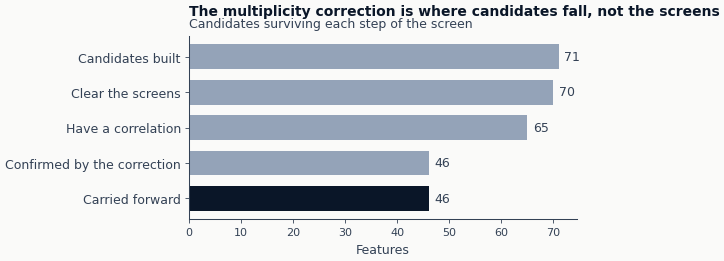

In [34]:
stage_counts = [
    ("Candidates built", len(all_feature_cols)),
    ("Clear the screens", len(evaluable_features)),
    ("Have a correlation", len(ic_stats)),
    ("Confirmed by the correction", len(fdr_significant)),
    ("Carried forward", sum(1 for d, _ in triage.values() if d == "PROCEED")),
]
fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.barh(
    range(len(stage_counts)),
    [n for _, n in stage_counts],
    color=[COLORS["recede"]] * (len(stage_counts) - 1) + [COLORS["blue"]],
    height=0.7,
)
for row, (_, n) in enumerate(stage_counts):
    ax.annotate(
        f"{n}", (n, row), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9
    )
ax.set_yticks(range(len(stage_counts)), [name for name, _ in stage_counts], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Features")
add_message_title(
    ax,
    "The multiplicity correction is where candidates fall, not the screens",
    subtitle="Candidates surviving each step of the screen",
)
show_with_alt(
    fig,
    "Horizontal bar chart of five steps of the screen, from candidates built down to "
    "features carried forward, with the count annotated at the end of each bar. The first "
    "three bars are nearly the same length; the drop happens at the multiplicity "
    "correction, and the last bar matches it exactly because the exploration route "
    "promotes nothing here.",
)

In [35]:
promoted = ledger.filter(pl.col("decision") == "PROCEED")
print(ledger.group_by("decision").len().sort("decision"))
print(promoted.group_by("note").len().sort("note"))
print(f"Promoted features span {promoted['family'].n_unique()} of {len(set(families.values()))}")
print(f"families; {len(pairs)} screened pairs correlate above {REDUNDANCY_CUT:.2f}")

shape: (3, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 46  │
│ REVISE   ┆ 24  │
│ STOP     ┆ 1   │
└──────────┴─────┘
shape: (1, 2)
┌─────────────────┬─────┐
│ note            ┆ len │
│ ---             ┆ --- │
│ str             ┆ u32 │
╞═════════════════╪═════╡
│ fdr_significant ┆ 46  │
└─────────────────┴─────┘
Promoted features span 9 of 11
families; 248 screened pairs correlate above 0.70


The screen carries 46 features forward, marks 24 for revision and stops 1 on coverage and
staleness. All 46 came through the false-discovery correction and none through the
exploration route, whose bar - the median association among the candidates that got one -
stands at 0.0066 on this panel. The features carried forward span 9 of the 11 families,
and 248 pairs among the screened candidates correlate above 0.70, so the count of
promotions is comfortably larger than the count of distinct ideas behind them.

## Key takeaways

1. **Screen one feature at a time, then stop.** This stage says which candidates carry
   information about the label and how reliably; it does not say which set to train on.
   Two features that duplicate each other both pass here, and it is the model that has to
   choose between them.

2. **The seal is on the label's endpoint, not on the decision date.** Stopping the panel
   at the holdout boundary would still let the last few decisions be scored by returns
   that resolve inside it. Counting the horizon on the trading calendar the panel actually
   uses is what makes the boundary hold across holidays.

3. **Breadth buys precision, not size.** Averaging a cross-sectional correlation over a
   wide panel and a long history gives a tight interval around a small number. It does not
   make the number large, and a screen reporting significance without reporting the size
   of the association invites the reader to confuse the two.

4. **Correct the interval for serial correlation, and the p-values for the search.** These
   are different corrections for different problems: the first because consecutive daily
   correlations are not independent draws, the second because many features were tried at
   once. Applying one is not applying the other, and on a one-session label the first can
   cost almost nothing while the second still bites.

5. **Measure fold stability against the feature's own direction.** Counting positive folds
   scores a steady inverse predictor at zero, so a rule built on that count can never
   promote one, however reliable it is.

6. **Assign quantiles inside the decision time, and net out the session's own average.**
   Pooled bins let another period's distribution set this period's boundaries. Raw levels
   give every quintile the market's drift and hide the only difference a long-short book
   collects.

7. **A count of candidates is not a count of tests.** A feature and its within-session
   rank produce the same information coefficient to the last digit, and the multiplicity
   correction is told they are two independent tests. Read the corrected p-values
   against the duplication the redundancy section measures, not on their own.

**Known limitations.** Sixteen folds of one year each is a fine grid for stability and a
coarse one for regimes: a feature that works in expansions and not in contractions shows
as scattered folds rather than as two states. The redundancy clustering is measured on
sampled sessions and on the correlation of levels, so it finds duplicated construction
rather than duplicated information. The exploration route's bar moves with the panel, so
the same notebook on a different universe promotes a different set through it. And the
screen looks at one label horizon, so a feature whose association appears only over longer
holds is not visible here at all.

**Next**: [`06_linear`](06_linear.ipynb) fits the first models on this feature set, and
[`20_strategy_synthesis/02_feature_evaluation`](../../20_strategy_synthesis/02_feature_evaluation.ipynb)
reads the ledger written here for all nine case studies.